# 🔬 TP pratique : évaluer des modèles avec Scikit-Learn

**Durée indicative : 3 h — Usage strictement pédagogique, sans finalité médicale.**

## Objectifs observables

1. comparer OLS, Ridge et Lasso sans confondre régularisation et garantie de performance ;
2. déclarer explicitement la classe positive d'un problème binaire ;
3. lire matrice de confusion, rappel et ROC-AUC dans le même sens métier ;
4. séparer test final et validation croisée ;
5. interpréter une importance de variable comme un signal du modèle, pas comme une causalité.


## 1. Importation des bibliothèques

Scikit-Learn est découpé en sous-modules thématiques très clairs :
- `datasets` : Jeux de données d'entraînement et générateurs synthétiques.
- `linear_model` : Algorithmes linéaires (Régression standard, Ridge, Lasso, Régression Logistique).
- `ensemble` : Algorithmes combinant plusieurs arbres (Random Forest).
- `svm` : Séparateurs à vaste marge (Machines à Vecteurs de Support).
- `cluster` & `decomposition` : Modèles non supervisés (K-Means, PCA).
- `metrics` : Outils de mesure de performance (matrices de confusion, ROC, F1).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Données et séparation
from sklearn.datasets import make_regression, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

# Algorithmes de régression
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Algorithmes de classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Algorithmes non-supervisés
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Prétraitement et Pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Métriques
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline
print("Toutes les dépendances Scikit-Learn sont chargées !")


Toutes les dépendances Scikit-Learn sont chargées !


## 2. Régression et régularisation : Ridge vs Lasso

Créons un problème de régression synthétique avec 20 caractéristiques, dont 6 seulement contribuent à la cible. Les autres sont du bruit dans ce générateur ; il ne crée pas ici de variables redondantes explicites.


In [2]:
np.random.seed(42)
X_reg, y_reg = make_regression(
    n_samples=250, 
    n_features=20, 
    n_informative=6, 
    noise=15.0, 
    random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

# Entraînement des 3 modèles
lr = LinearRegression().fit(X_train_r, y_train_r)
ridge = Ridge(alpha=10.0).fit(X_train_r, y_train_r)
lasso = Lasso(alpha=2.5).fit(X_train_r, y_train_r)

print(f"R² OLS Standard (Test) : {r2_score(y_test_r, lr.predict(X_test_r)):.3f}")
print(f"R² Ridge L2 (Test)     : {r2_score(y_test_r, ridge.predict(X_test_r)):.3f}")
print(f"R² Lasso L1 (Test)     : {r2_score(y_test_r, lasso.predict(X_test_r)):.3f}")
print(f"Nombre de poids nuls chez Lasso : {np.sum(lasso.coef_ == 0)} sur 20")


R² OLS Standard (Test) : 0.973
R² Ridge L2 (Test)     : 0.971
R² Lasso L1 (Test)     : 0.970
Nombre de poids nuls chez Lasso : 14 sur 20


Visualisons les coefficients appris par chaque modèle pour constater l'effet de sparsité induit par la norme $L_1$ :


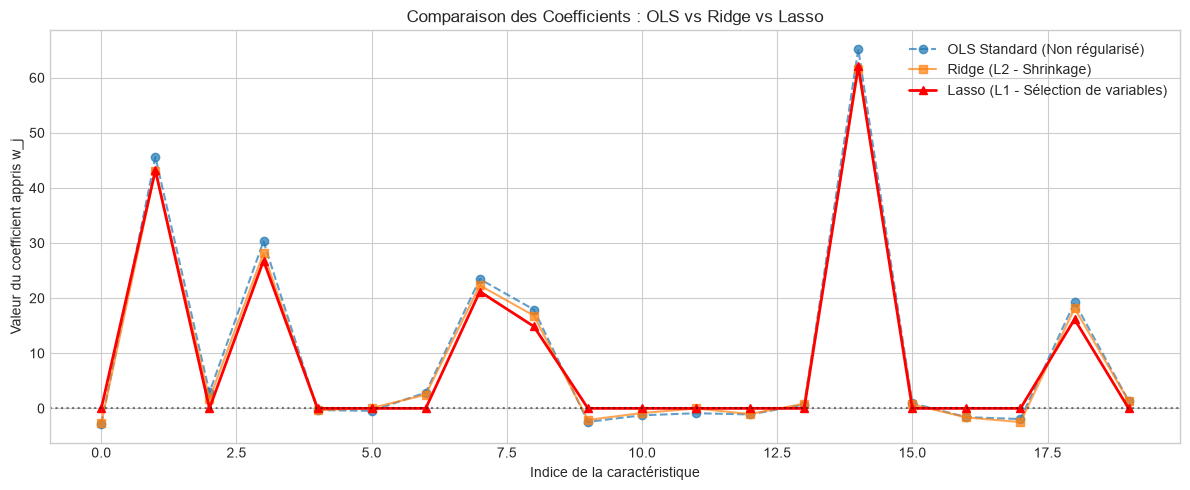

In [3]:
plt.figure(figsize=(12, 5))
x_axis = np.arange(len(lr.coef_))

plt.plot(x_axis, lr.coef_, 'o--', label="OLS Standard (Non régularisé)", alpha=0.7)
plt.plot(x_axis, ridge.coef_, 's-', label="Ridge (L2 - Shrinkage)", alpha=0.7)
plt.plot(x_axis, lasso.coef_, '^-', label="Lasso (L1 - Sélection de variables)", color='red', lw=2)

plt.axhline(0, color='black', linestyle=':', alpha=0.5)
plt.xlabel("Indice de la caractéristique")
plt.ylabel("Valeur du coefficient appris w_j")
plt.title("Comparaison des Coefficients : OLS vs Ridge vs Lasso")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Classification binaire : convention de classe positive

Le jeu **Breast Cancer Wisconsin Diagnostic** contient 30 mesures calculées sur des images de noyaux cellulaires. Dans Scikit-Learn, la cible d'origine code `0 = malignant` et `1 = benign`.

Pour aligner toutes les métriques avec la question « combien de tumeurs malignes détecte-t-on ? », nous recodons explicitement **`1 = maligne`**. L'AUC, le rappel et le score utilisé par `GridSearchCV` auront ainsi le même sens.

> Ce jeu illustre une méthode statistique. Il ne permet ni diagnostic clinique ni estimation d'efficacité médicale réelle.


In [4]:
data = load_breast_cancer()
X_c = data.data
y_c = (data.target == 0).astype(int)  # Convention du TP : 1 = maligne.
class_names = ['Bénigne (0)', 'Maligne (1)']

assert y_c.sum() == 212, "Le recodage de la classe maligne a changé."

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c,
    y_c,
    test_size=0.30,
    random_state=42,
    stratify=y_c,
)

models = {
    "Régression logistique": Pipeline([
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Forêt aléatoire": RandomForestClassifier(
        n_estimators=150, random_state=42, n_jobs=1
    ),
    "SVM": Pipeline([
        ('scale', StandardScaler()),
        ('clf', SVC(random_state=42)),
    ]),
}

results = {}
for name, model in models.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)
    if hasattr(model, "decision_function"):
        score_maligne = model.decision_function(X_test_c)
    else:
        positive_index = list(model.classes_).index(1)
        score_maligne = model.predict_proba(X_test_c)[:, positive_index]
    auc = roc_auc_score(y_test_c, score_maligne)
    results[name] = {
        "model": model,
        "pred": y_pred,
        "score": score_maligne,
        "auc": auc,
    }
    print(f"=== {name} ===")
    print(f"ROC-AUC, positif = maligne : {auc:.4f}")
    print(classification_report(
        y_test_c,
        y_pred,
        labels=[0, 1],
        target_names=class_names,
        zero_division=0,
    ))


=== Régression logistique ===
ROC-AUC, positif = maligne : 0.9975
              precision    recall  f1-score   support

 Bénigne (0)       0.96      0.99      0.98       107
 Maligne (1)       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



=== Forêt aléatoire ===
ROC-AUC, positif = maligne : 0.9961
              precision    recall  f1-score   support

 Bénigne (0)       0.96      1.00      0.98       107
 Maligne (1)       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171

=== SVM ===
ROC-AUC, positif = maligne : 0.9972
              precision    recall  f1-score   support

 Bénigne (0)       0.94      1.00      0.97       107
 Maligne (1)       1.00      0.89      0.94        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



Affichons la matrice de confusion et les courbes ROC :


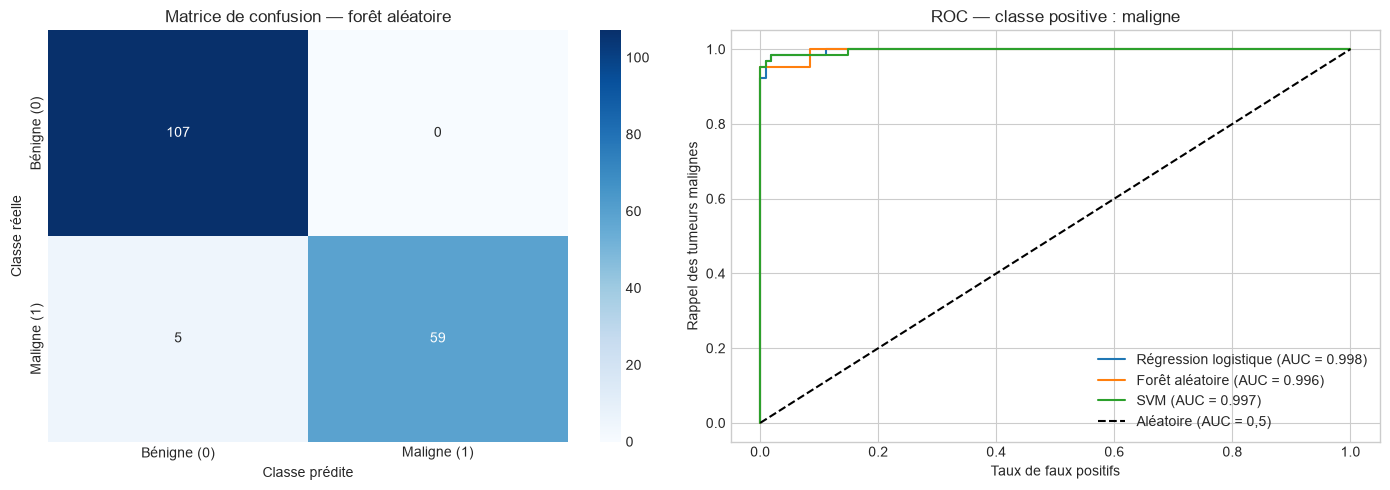

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_c, results["Forêt aléatoire"]["pred"], labels=[0, 1])
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=class_names,
    yticklabels=class_names,
)
axes[0].set_title("Matrice de confusion — forêt aléatoire")
axes[0].set_ylabel("Classe réelle")
axes[0].set_xlabel("Classe prédite")

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test_c, result["score"], pos_label=1)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC = {result['auc']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0,5)")
axes[1].set_title("ROC — classe positive : maligne")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Rappel des tumeurs malignes")
axes[1].legend()
plt.tight_layout()
plt.show()

assert cm.sum() == len(y_test_c)


## 4. Apprentissage Non-Supervisé : K-Means & ACP (PCA)

Utilisons le jeu de données **Wine** (13 attributs chimiques). Nous allons regrouper les échantillons sans fournir les étiquettes de cépages, puis visualiser les clusters en 2D grâce à la PCA.


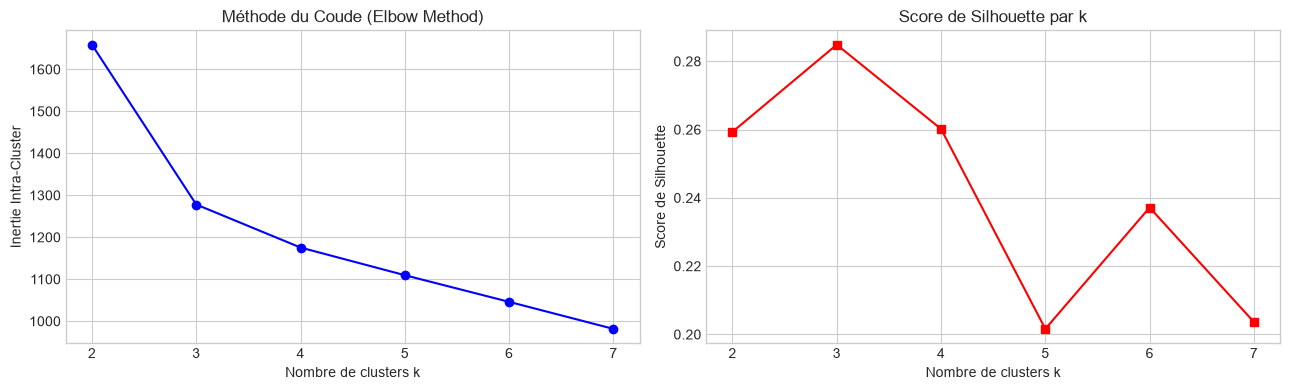

In [6]:
wine = load_wine()
X_w = wine.data
scaler = StandardScaler()
X_w_scaled = scaler.fit_transform(X_w)

# Recherche du k optimal (Méthode du coude & Score Silhouette)
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_w_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_w_scaled, kmeans.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(k_range, inertias, 'bo-')
ax[0].set_title("Méthode du Coude (Elbow Method)")
ax[0].set_xlabel("Nombre de clusters k")
ax[0].set_ylabel("Inertie Intra-Cluster")

ax[1].plot(k_range, silhouettes, 'rs-')
ax[1].set_title("Score de Silhouette par k")
ax[1].set_xlabel("Nombre de clusters k")
ax[1].set_ylabel("Score de Silhouette")
plt.tight_layout()
plt.show()


Projetons maintenant les données dans l'espace des 2 premières composantes principales (PCA) et colorons avec les clusters K-Means ($k=3$) :


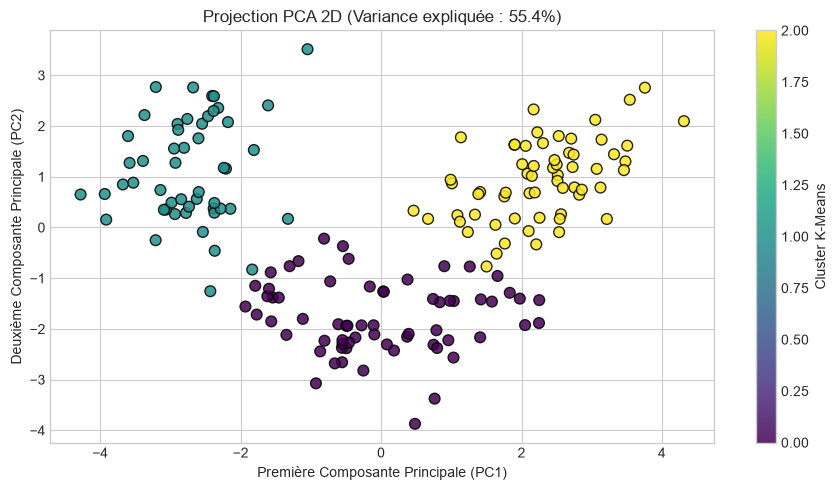

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_w_scaled)

best_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_w_scaled)
cluster_labels = best_kmeans.labels_

plt.figure(figsize=(9, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=60, edgecolors='k', alpha=0.85)
plt.title(f"Projection PCA 2D (Variance expliquée : {pca.explained_variance_ratio_.sum():.1%})")
plt.xlabel("Première Composante Principale (PC1)")
plt.ylabel("Deuxième Composante Principale (PC2)")
plt.colorbar(scatter, label="Cluster K-Means")
plt.tight_layout()
plt.show()


## 5. Pipeline et optimisation par validation croisée

Le `StandardScaler` et le classifieur sont encapsulés dans le même `Pipeline`. À chaque pli, le scaler est ainsi ajusté uniquement sur la partie d'entraînement du pli. Le test final reste inutilisé jusqu'à l'évaluation finale.


In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC()),
])

param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.01, 0.1],
    'svc__kernel': ['rbf', 'linear'],
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='recall',  # y=1 correspond explicitement à « maligne ».
    n_jobs=1,
)
grid_search.fit(X_train_c, y_train_c)

print("Meilleurs paramètres de la grille :", grid_search.best_params_)
print(f"Rappel malin moyen en CV : {grid_search.best_score_:.4f}")
print(f"Rappel malin sur le test final : {grid_search.score(X_test_c, y_test_c):.4f}")


Meilleurs paramètres de la grille : {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Rappel malin moyen en CV : 0.9526
Rappel malin sur le test final : 0.9062


## 6. Exercice guidé : optimiser une forêt pour le rappel malin

1. Créez un pipeline contenant une forêt aléatoire. Un scaler n'est pas nécessaire pour cet arbre.
2. Comparez plusieurs valeurs de `n_estimators` et `max_depth` avec le même `StratifiedKFold`.
3. Optimisez le rappel de la classe `1 = maligne`.
4. Affichez les dix importances les plus élevées et formulez une limite d'interprétation.

**Critère de réussite** : le code ne consulte le test qu'après la sélection des hyperparamètres.


In [9]:
# À vous de jouer.
# TODO : définir pipe_rf, param_grid_rf et grid_rf, puis ajuster sur X_train_c.


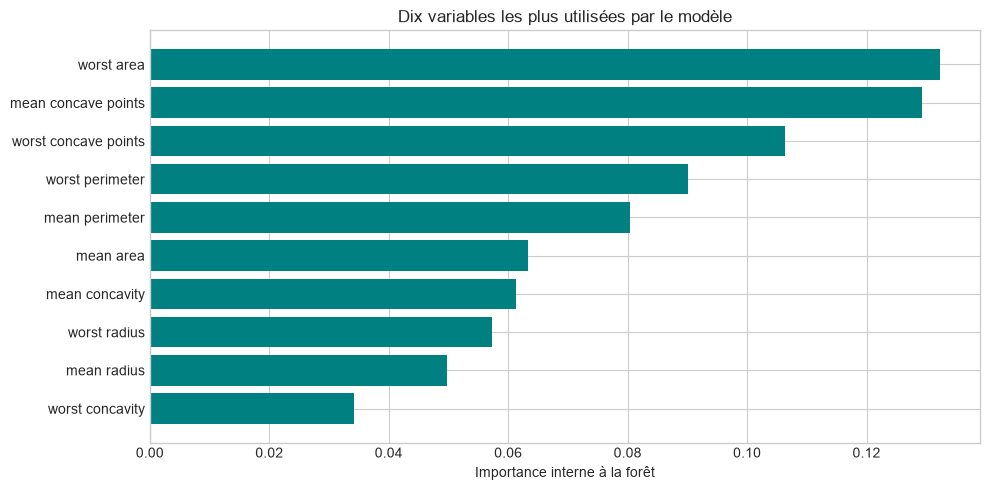

Meilleurs paramètres : {'rf__max_depth': 6, 'rf__n_estimators': 75}
Rappel malin sur test : 0.9062
Variables en tête : ['worst area', 'mean concave points', 'worst concave points']
Limite : ces importances peuvent être partagées entre variables corrélées et ne démontrent aucune relation causale.


In [10]:
# Solution
pipe_rf = Pipeline([
    ('rf', RandomForestClassifier(random_state=42, n_jobs=1)),
])
param_grid_rf = {
    'rf__n_estimators': [75, 150],
    'rf__max_depth': [3, 6, None],
}
grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=cv_strategy,
    scoring='recall',
    n_jobs=1,
)
grid_rf.fit(X_train_c, y_train_c)

best_rf_model = grid_rf.best_estimator_.named_steps['rf']
importances = best_rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 5))
plt.barh(
    range(10),
    importances[indices][::-1],
    align='center',
    color='teal',
)
plt.yticks(range(10), [data.feature_names[i] for i in indices][::-1])
plt.xlabel("Importance interne à la forêt")
plt.title("Dix variables les plus utilisées par le modèle")
plt.tight_layout()
plt.show()

print("Meilleurs paramètres :", grid_rf.best_params_)
print(f"Rappel malin sur test : {grid_rf.score(X_test_c, y_test_c):.4f}")
print("Variables en tête :", [str(data.feature_names[i]) for i in indices[:3]])
print(
    "Limite : ces importances peuvent être partagées entre variables corrélées et "
    "ne démontrent aucune relation causale."
)


## Conclusion et auto-évaluation

Avant de quitter le TP, vérifiez que vous savez :

1. retrouver la convention d'une cible dans sa documentation ;
2. expliquer pourquoi `1 = maligne` aligne rappel, ROC-AUC et objectif métier ;
3. distinguer validation croisée et test final ;
4. présenter une importance de variable sans la confondre avec une causalité.
